<a href="https://colab.research.google.com/github/ngyxntthaoo/IS6404.CH201-Phan-tich-du-lieu-nang-cao/blob/main/Getting_started_with_google_colab_ai_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx matplotlib

Choosing a Model
The model names give you a hint about their capabilities and intended use:

Pro: These are the most capable models, ideal for complex reasoning, creative tasks, and detailed analysis.

Flash: These models are optimized for high speed and efficiency, making them great for summarization, chat applications, and tasks requiring rapid responses.

Gemma: These are lightweight, open-weight models suitable for a variety of text generation tasks and are great for experimentation.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

In [ ]:
def create_process(edges):
    G = nx.DiGraph()
    for u, v in edges:
        G.add_edge(u, v)
    return G

In [ ]:
edges1 = [
    ("Start","Receive"),
    ("Receive","Verify"),
    ("Verify","Check"),
    ("Check","Approve"),
    ("Approve","Create"),
    ("Create","End"),
]

G1 = create_process(edges1)

In [ ]:
edges2 = [
    ("Start","Receive"),
    ("Receive","Verify"),
    ("Verify","Check"),
    ("Check","Approve"),
    ("Approve","Disburse"),
    ("Disburse","End"),
]

G2 = create_process(edges2)

In [ ]:
edges3 = [
    ("Start","Receive"),
    ("Receive","Verify"),
    ("Verify","Check"),
    ("Check","Approve"),
    ("Approve","IssueCard"),
    ("IssueCard","End"),
]

G3 = create_process(edges3)

In [ ]:
graphs = [G1, G2, G3]

In [ ]:
def contains_subgraph(G, sub_edges):
    for u, v in sub_edges:
        if not G.has_edge(u, v):
            return False
    return True

In [ ]:
def generate_subgraphs(G, size):

    edges = list(G.edges())

    subs = []

    for comb in combinations(edges, size):
        subs.append(list(comb))

    return subs

In [ ]:
def support(sub_edges, graphs):

    count = 0

    for G in graphs:
        if contains_subgraph(G, sub_edges):
            count += 1

    return count

In [ ]:
minsup = 3

frequent = []

subs = generate_subgraphs(G1, 3)

for s in subs:

    sup = support(s, graphs)

    if sup >= minsup:
        frequent.append((s, sup))

frequent

[([('Start', 'Receive'), ('Receive', 'Verify'), ('Verify', 'Check')], 3),
 ([('Start', 'Receive'), ('Receive', 'Verify'), ('Check', 'Approve')], 3),
 ([('Start', 'Receive'), ('Verify', 'Check'), ('Check', 'Approve')], 3),
 ([('Receive', 'Verify'), ('Verify', 'Check'), ('Check', 'Approve')], 3)]

In [ ]:
subs = generate_subgraphs(G1, 4)
frequent = []
for s in subs:
    sup = support(s, graphs)
    if sup >= 3:
        frequent.append((s, sup))

frequent

[([('Start', 'Receive'),
   ('Receive', 'Verify'),
   ('Verify', 'Check'),
   ('Check', 'Approve')],
  3)]

In [ ]:
def draw_subgraph(edges):

    G = nx.DiGraph()

    for u, v in edges:
        G.add_edge(u, v)

    pos = nx.spring_layout(G)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        node_size=2000,
        font_size=10,
        arrows=True
    )

    plt.show()

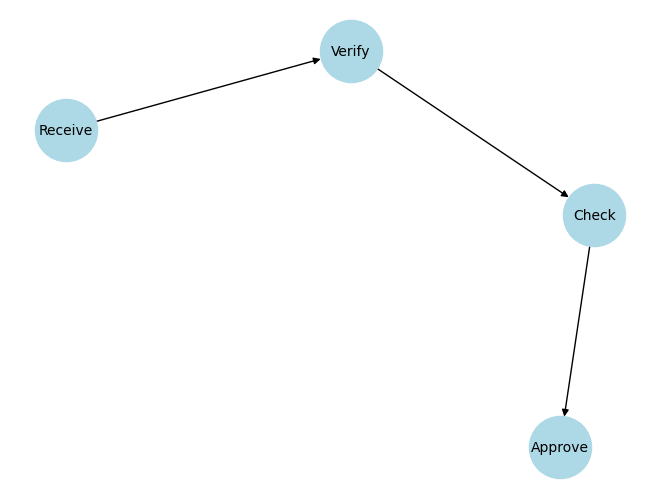

In [ ]:
kyc = [
    ("Receive","Verify"),
    ("Verify","Check"),
    ("Check","Approve"),
]

draw_subgraph(kyc)

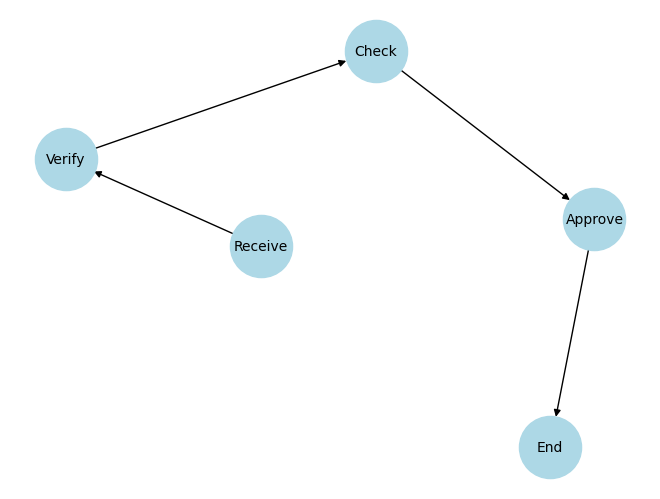

In [ ]:
draw_subgraph([
    ("Receive","Verify"),
    ("Verify","Check"),
    ("Check","Approve"),
    ("Approve","End"),
])

## Process Mining cua Thay

In [ ]:
# Cập nhật lên phiên bản mới nhất
!pip install --upgrade pm4py

# Hoặc cài đặt phiên bản cụ thể
!pip install pm4py==2.7.0

  Using cached pm4py-2.7.22-py3-none-any.whl.metadata (4.7 kB)
Using cached pm4py-2.7.22-py3-none-any.whl (2.5 MB)
  Attempting uninstall: pm4py
    Found existing installation: pm4py 2.7.0
    Uninstalling pm4py-2.7.0:
      Successfully uninstalled pm4py-2.7.0
  Using cached pm4py-2.7.0-py3-none-any.whl.metadata (3.1 kB)
Using cached pm4py-2.7.0-py3-none-any.whl (1.6 MB)
  Attempting uninstall: pm4py
    Found existing installation: pm4py 2.7.22
    Uninstalling pm4py-2.7.22:
      Successfully uninstalled pm4py-2.7.22


/usr/local/lib/python3.12/dist-packages/pm4py/objects/log/util/dataframe_utils.py:176: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], utc=True)
/usr/local/lib/python3.12/dist-packages/pm4py/objects/log/util/dataframe_utils.py:176: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], utc=True)


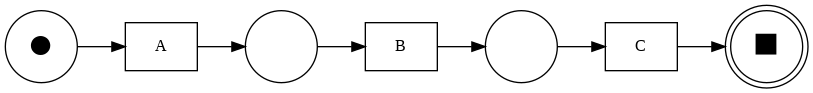

In [ ]:
#Alpha Miner
import pm4py
from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.visualization.petri_net import visualizer as pn_visualizer
import pandas as pd

# 1. Tạo dữ liệu mẫu (Event Log)
# Trong thực tế, anh có thể đọc từ file .csv hoặc .xes
event_data = {
    'case:concept:name': ['1', '1', '1', '2', '2', '2', '3', '3', '3'],
    'concept:name': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C'],
    'time:timestamp': pd.to_datetime([
        '2026-01-01 09:00', '2026-01-01 10:00', '2026-01-01 11:00',
        '2026-01-02 09:00', '2026-01-02 10:00', '2026-01-02 11:00',
        '2026-01-03 09:00', '2026-01-03 10:00', '2026-01-03 11:00'
    ])
}

df = pd.DataFrame(event_data)
df = dataframe_utils.convert_timestamp_columns_in_df(df)
df = df.sort_values('time:timestamp')

# Chuyển đổi DataFrame sang định dạng Log của pm4py
log = log_converter.apply(df)

# 2. Áp dụng thuật toán Alpha Miner
# Kết quả trả về gồm: Petri net (net), Trạng thái bắt đầu (im), Trạng thái kết thúc (fm)
net, initial_marking, final_marking = alpha_miner.apply(log)

# 3. Trực quan hóa mô hình Petri net
gviz = pn_visualizer.apply(net, initial_marking, final_marking)
pn_visualizer.view(gviz)

# 4. (Tùy chọn) Xuất file ảnh
# pn_visualizer.save(gviz, "alpha_miner_result.png")

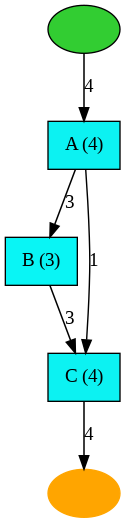

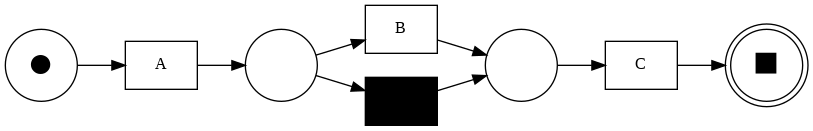

In [ ]:
# Heuristic Mining

import pm4py
import pandas as pd

# 1. Tạo dữ liệu mẫu trực tiếp bằng DataFrame
event_data = {
    'case:concept:name': ['1', '1', '1', '2', '2', '2', '3', '3', '3', '4', '4'],
    'concept:name': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C', 'A', 'C'],
    'time:timestamp': pd.to_datetime([
        '2026-01-01 09:00', '2026-01-01 10:00', '2026-01-01 11:00',
        '2026-01-02 09:00', '2026-01-02 10:00', '2026-01-02 11:00',
        '2026-01-03 09:00', '2026-01-03 10:00', '2026-01-03 11:00',
        '2026-01-04 09:00', '2026-01-04 10:00'
    ])
}
df = pd.DataFrame(event_data)

# 2. Khám phá Heuristics Net bằng hàm High-level
# Hàm này tự động xử lý việc chuyển đổi log và áp dụng thuật toán
heu_net = pm4py.discover_heuristics_net(df,
                                        dependency_threshold=0.5,
                                        case_id_key='case:concept:name',
                                        activity_key='concept:name',
                                        timestamp_key='time:timestamp')

# 3. Trực quan hóa
pm4py.view_heuristics_net(heu_net)

# 4. Nếu anh muốn chuyển sang Petri Net để phân tích toán học (Soundness)
net, im, fm = pm4py.discover_petri_net_heuristics(df,
                                                dependency_threshold=0.5,
                                                case_id_key='case:concept:name',
                                                activity_key='concept:name',
                                                timestamp_key='time:timestamp')
pm4py.view_petri_net(net, im, fm)

Đã chuyển đổi thành công Petri Net sang BPMN
BPMN Graph: ->( 'A', X( tau, 'B' ), X( tau, 'C' ) )


/usr/local/lib/python3.12/dist-packages/pm4py/utils.py:486: UserWarning: the EventLog class has been deprecated and will be removed in a future release.
  warnings.warn("the EventLog class has been deprecated and will be removed in a future release.")


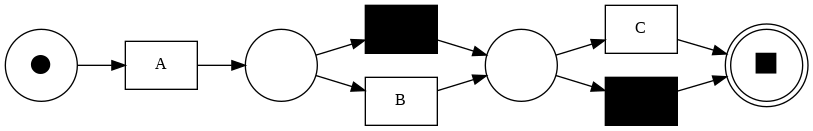

In [ ]:
# Bien Petrinet thanh BPMN
import pm4py
from pm4py.objects.conversion.log import converter as log_converter
import pandas as pd

# Import các module cần thiết cho BPMN
from pm4py.objects.conversion.wf_net import converter as wf_converter
from pm4py.objects.bpmn.exporter import exporter as bpmn_exporter


# 1. Tạo dữ liệu mẫu và khám phá Petri Net bằng Inductive Miner
event_data = {
    'case:concept:name': ['1', '1', '1', '2', '2', '2', '3', '3', '4', '4'],
    'concept:name': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'C', 'A', 'B'],
    'time:timestamp': pd.to_datetime([
        '2026-01-01 09:00', '2026-01-01 10:00', '2026-01-01 11:00',
        '2026-01-02 09:00', '2026-01-02 10:00', '2026-01-02 11:00',
        '2026-01-03 09:00', '2026-01-03 10:00', '2026-01-04 09:00', '2026-01-04 10:00'
    ])
}
df = pd.DataFrame(event_data)

# Chuyển đổi DataFrame thành event log
event_log = log_converter.apply(df, variant=log_converter.Variants.TO_EVENT_LOG)

# Khám phá Petri Net
net, im, fm = pm4py.discover_petri_net_inductive(event_log)

# 2. Chuyển đổi Petri Net sang mô hình BPMN
# Sử dụng đúng cách import và hàm chuyển đổi
bpmn_graph = wf_converter.apply(net, im, fm)

# 3. Trực quan hóa kết quả BPMN
print("Đã chuyển đổi thành công Petri Net sang BPMN")
print(f"BPMN Graph: {bpmn_graph}")

# Hiển thị thông tin về BPMN graph
if hasattr(bpmn_graph, 'get_nodes'):
    print(f"Số lượng node trong BPMN: {len(bpmn_graph.get_nodes())}")

# 4. Xuất file BPMN (nếu muốn)
# bpmn_exporter.apply(bpmn_graph, "process_model.bpmn")
# print("Đã xuất file process_model.bpmn")

# 5. Hiển thị Petri Net để so sánh
pm4py.view_petri_net(net, im, fm)

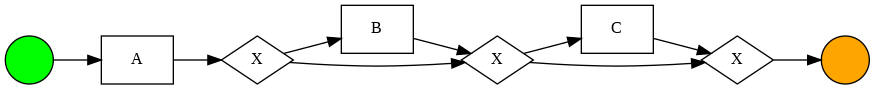

In [ ]:
## Bien Petrinet thanh BPMN
import pm4py
import pandas as pd

# 1. Tạo dữ liệu mẫu
event_data = {
    'case:concept:name': ['1', '1', '1', '2', '2', '2', '3', '3', '4', '4'],
    'concept:name': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'C', 'A', 'B'],
    'time:timestamp': pd.to_datetime([
        '2026-01-01 09:00', '2026-01-01 10:00', '2026-01-01 11:00',
        '2026-01-02 09:00', '2026-01-02 10:00', '2026-01-02 11:00',
        '2026-01-03 09:00', '2026-01-03 10:00', '2026-01-04 09:00', '2026-01-04 10:00'
    ])
}
df = pd.DataFrame(event_data)

# 2. Khám phá Petri Net bằng Inductive Miner (High-level)
net, im, fm = pm4py.discover_petri_net_inductive(df)

# 3. CHUYỂN ĐỔI: Sử dụng hàm trực tiếp từ pm4py
# Đây là cách thay thế cho module pn_to_bpmn_converter cũ
bpmn_graph = pm4py.convert_to_bpmn(net, im, fm)

# 4. Trực quan hóa
pm4py.view_bpmn(bpmn_graph)

# 5. Lưu ra file để đồng nghiệp mở bằng Camunda/Bizagi (nếu cần)
# pm4py.write_bpmn(bpmn_graph, "model_ket_qua.bpmn")

Đã lưu event log vào: /content/sample_data/event_log.csv
Số lượng cases: 5
Số lượng events: 20

Preview của event log:
  case:concept:name             concept:name      time:timestamp
0                 1         Inspect Building 2026-03-17 08:00:00
1                 1      Complete Inspection 2026-03-17 09:00:00
2                 1  Send Email Notification 2026-03-17 09:10:00
3                 1          Prepare Invoice 2026-03-17 10:00:00
4                 1         Generate Invoice 2026-03-17 10:30:00
5                 2         Inspect Building 2026-03-17 08:15:00
6                 2     Inspection Cancelled 2026-03-17 08:45:00
7                 3         Inspect Building 2026-03-17 08:30:00
8                 3      Complete Inspection 2026-03-17 09:30:00
9                 3  Send Email Notification 2026-03-17 09:40:00


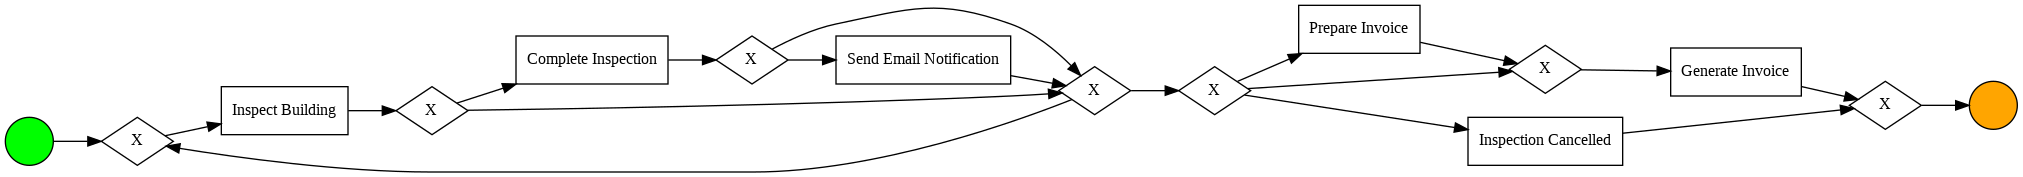

In [ ]:
## Ve so do BPMN
import pm4py
import pandas as pd

# 1. Khởi tạo dữ liệu (Dựa trên kịch bản Building Inspection đã tạo ở trên)
event_data = {
    'case:concept:name': [
        '1', '1', '1', '1', '1',
        '2', '2',
        '3', '3', '3', '3', '3', '3',
        '4', '4', '4', '4', '4',
        '5', '5'
    ],
    'concept:name': [
        'Inspect Building', 'Complete Inspection', 'Send Email Notification', 'Prepare Invoice', 'Generate Invoice',
        'Inspect Building', 'Inspection Cancelled',
        'Inspect Building', 'Complete Inspection', 'Send Email Notification', 'Inspect Building', 'Complete Inspection', 'Generate Invoice',
        'Inspect Building', 'Complete Inspection', 'Send Email Notification', 'Prepare Invoice', 'Generate Invoice',
        'Inspect Building', 'Inspection Cancelled'
    ],
    'time:timestamp': pd.to_datetime([
        '2026-03-17 08:00', '2026-03-17 09:00', '2026-03-17 09:10', '2026-03-17 10:00', '2026-03-17 10:30',
        '2026-03-17 08:15', '2026-03-17 08:45',
        '2026-03-17 08:30', '2026-03-17 09:30', '2026-03-17 09:40', '2026-03-17 11:00', '2026-03-17 12:00', '2026-03-17 12:30',
        '2026-03-18 08:00', '2026-03-18 09:00', '2026-03-18 09:15', '2026-03-18 10:00', '2026-03-18 10:45',
        '2026-03-18 08:30', '2026-03-18 09:00'
    ])
}

df = pd.DataFrame(event_data)
# LƯU EVENT LOG VÀO FILE CSV
# Đường dẫn lưu file
csv_path = '/content/sample_data/event_log.csv'

# Lưu DataFrame thành file CSV
df.to_csv(csv_path, index=False, encoding='utf-8')
print(f"Đã lưu event log vào: {csv_path}")
print(f"Số lượng cases: {df['case:concept:name'].nunique()}")
print(f"Số lượng events: {len(df)}")
print("\nPreview của event log:")
print(df.head(10))
# 2. Khám phá mô hình bằng Inductive Miner
# Thuật toán này rất mạnh trong việc phát hiện loop và branch từ log
net, im, fm = pm4py.discover_petri_net_inductive(df,
                                                 case_id_key='case:concept:name',
                                                 activity_key='concept:name',
                                                 timestamp_key='time:timestamp')

# 3. Chuyển đổi Petri Net vừa khám phá sang định dạng BPMN
bpmn_graph = pm4py.convert_to_bpmn(net, im, fm)

# 4. Trực quan hóa sơ đồ BPMN
pm4py.view_bpmn(bpmn_graph)

# 5. (Tùy chọn) Xuất file để kiểm tra cấu trúc XML
# pm4py.write_bpmn(bpmn_graph, "building_inspection_model.bpmn")

In [ ]:
!pip install graphviz

In [ ]:
### Ve BPMN Diagram
from graphviz import Digraph

# Create BPMN diagram
bpmn = Digraph('BPMN', format='png')
bpmn.attr(rankdir='LR')  # Left to Right layout

# Start Event
bpmn.node('Start', shape='circle', label='Start')

# Tasks
bpmn.node('T1', shape='box')
bpmn.node('T2', shape='box')
bpmn.node('T3', shape='box')
bpmn.node('T4', shape='box')

# Gateways (XOR)
bpmn.node('G1', shape='diamond', label='check')
bpmn.node('G2', shape='diamond')

# End Event
bpmn.node('End', shape='doublecircle', label='End')

# Edges
bpmn.edge('Start', 'T1')
bpmn.edge('T1', 'G1')

# XOR split
bpmn.edge('G1', 'T2', label='Y')
bpmn.edge('G1', 'T3', label='N')

# Merge gateway
bpmn.edge('T2', 'G2')
bpmn.edge('T3', 'G2')

# Continue
bpmn.edge('G2', 'T4')
bpmn.edge('T4', 'End')

# Render diagram
bpmn.render('bpmn_diagram', view=True)

'bpmn_diagram.png'

In [ ]:
### Ve PetriNet
from graphviz import Digraph

pn = Digraph("PetriNet", format="png")
pn.attr(rankdir="LR")

# ----- Places (circles) -----
places = ["P0","P1","P2","P3","P4","P5","P6"]
for p in places:
    pn.node(p, shape="circle")

# ----- Transitions (rectangles) -----
transitions = {
    "T1":"T1",
    "T2":"T2",
    "T3":"T3",
    "T4":"T4",
    "X1":"XOR",
    "X2":"XOR"
}

for t,label in transitions.items():
    pn.node(t, label=label, shape="box")

# ----- Flow relation -----

# Start
pn.edge("P0","T1")
pn.edge("T1","P1")

# XOR split
pn.edge("P1","X1")
pn.edge("X1","P2")
pn.edge("X1","P3")

# Branch tasks
pn.edge("P2","T2")
pn.edge("T2","P4")

pn.edge("P3","T3")
pn.edge("T3","P5")

# XOR merge
pn.edge("P4","X2")
pn.edge("P5","X2")

pn.edge("X2","P6")

# Final task
pn.edge("P6","T4")
pn.edge("T4","P0_end")

# End place
pn.node("P0_end", shape="doublecircle", label="End")

# Render
pn.render("petri_net_bpmn", view=True)

'petri_net_bpmn.png'

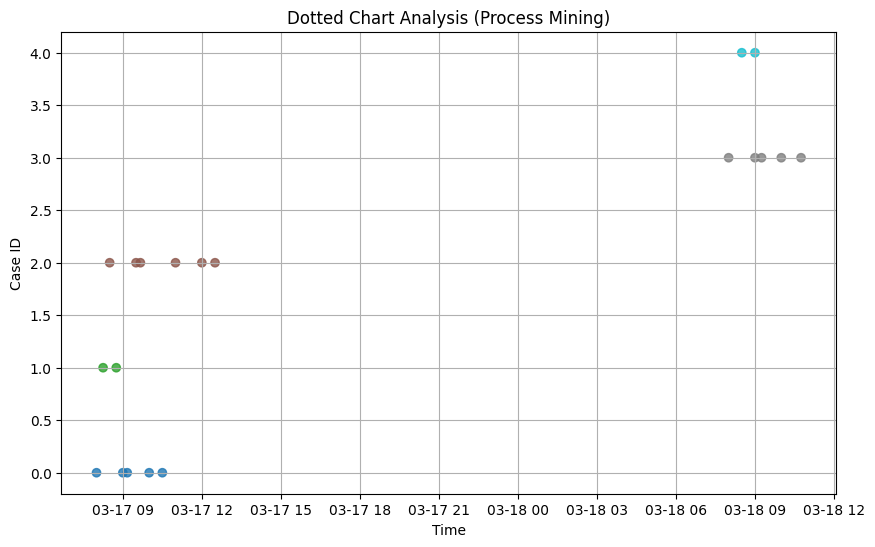

In [ ]:
## Chương trình Python Dotted Chart Analysis
import pandas as pd
import matplotlib.pyplot as plt

# Load event log
log = pd.read_csv("/content/sample_data/event_log.csv")

# Convert timestamp
log["time:timestamp"] = pd.to_datetime(log["time:timestamp"])

# Sort events
log = log.sort_values("time:timestamp")

# Map case_id to numeric values
log["case_num"] = log["case:concept:name"].astype("category").cat.codes

# Plot dotted chart
plt.figure(figsize=(10,6))

plt.scatter(
    log["time:timestamp"],
    log["case_num"],
    c=log["case_num"],
    cmap="tab10",
    alpha=0.8
)

plt.xlabel("Time")
plt.ylabel("Case ID")
plt.title("Dotted Chart Analysis (Process Mining)")

plt.grid(True)
plt.show()

In [ ]:
### Python Code: Decision Tree Mining
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load event log
log = pd.read_csv("/content/sample_data/event_log_1.csv")

# Encode categorical data
le_customer = LabelEncoder()
le_decision = LabelEncoder()

log["customer_type"] = le_customer.fit_transform(log["customer_type"])
log["decision"] = le_decision.fit_transform(log["decision"])

# Features and target
X = log[["amount", "customer_type"]]
y = log["decision"]

# Train decision tree
model = DecisionTreeClassifier(max_depth=3)
model.fit(X, y)

# Plot decision tree
plt.figure(figsize=(10,6))
plot_tree(
    model,
    feature_names=["amount", "customer_type"],
    class_names=le_decision.classes_,
    filled=True
)

plt.title("Decision Tree Mining (Process Mining)")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/event_log_1.csv'

In [ ]:
## Frequent Subgraph Mining
import networkx as nx
from itertools import combinations

# -----------------------------
# Tao tap do thi vi du
# -----------------------------
def create_graph_dataset():
    graphs = []

    # Graph 1
    g1 = nx.Graph()
    g1.add_edge("A", "B", label="x")
    g1.add_edge("B", "C", label="y")
    graphs.append(g1)

    # Graph 2
    g2 = nx.Graph()
    g2.add_edge("A", "B", label="x")
    g2.add_edge("B", "D", label="z")
    graphs.append(g2)

    # Graph 3
    g3 = nx.Graph()
    g3.add_edge("A", "B", label="x")
    g3.add_edge("B", "C", label="y")
    graphs.append(g3)

    return graphs


# -----------------------------
# Kiem tra subgraph isomorphism
# -----------------------------
def is_subgraph(g_small, g_large):
    matcher = nx.algorithms.isomorphism.GraphMatcher(g_large, g_small)
    return matcher.subgraph_is_isomorphic()


# -----------------------------
# Tao tat ca subgraph tu graph
# -----------------------------
def generate_subgraphs(graph):
    nodes = list(graph.nodes())
    subgraphs = []

    for r in range(2, len(nodes) + 1):
        for subset in combinations(nodes, r):
            sg = graph.subgraph(subset).copy()
            if sg.number_of_edges() > 0:
                subgraphs.append(sg)

    return subgraphs


# -----------------------------
# Frequent Subgraph Mining
# -----------------------------
def frequent_subgraph_mining(graphs, min_support=2):

    candidate_subgraphs = []

    for g in graphs:
        candidate_subgraphs.extend(generate_subgraphs(g))

    unique_subgraphs = []

    for sg in candidate_subgraphs:
        found = False

        for usg in unique_subgraphs:
            matcher = nx.algorithms.isomorphism.GraphMatcher(usg, sg)
            if matcher.is_isomorphic():
                found = True
                break

        if not found:
            unique_subgraphs.append(sg)

    results = []

    for sg in unique_subgraphs:
        support = 0

        for g in graphs:
            if is_subgraph(sg, g):
                support += 1

        if support >= min_support:
            results.append((sg, support))

    return results


# -----------------------------
# In ket qua
# -----------------------------
def print_results(results):

    for i, (sg, support) in enumerate(results):

        print("\nFrequent Subgraph", i + 1)
        print("Support:", support)

        print("Nodes:")
        for n in sg.nodes():
            print(n)

        print("Edges:")
        for u, v in sg.edges():
            print(u, "-", v)


# -----------------------------
# Main
# -----------------------------
def main():

    graphs = create_graph_dataset()

    min_support = 2

    results = frequent_subgraph_mining(graphs, min_support)

    print_results(results)


if __name__ == "__main__":
    main()

## Event log

In [ ]:
!pip install pm4py graphviz

!pip install --upgrade pm4py

# Hoặc cài đặt phiên bản cụ thể
!pip install pm4py==2.7.0

  Using cached pm4py-2.7.0-py3-none-any.whl.metadata (3.1 kB)
Using cached pm4py-2.7.0-py3-none-any.whl (1.6 MB)
  Attempting uninstall: pm4py
    Found existing installation: pm4py 2.7.22
    Uninstalling pm4py-2.7.22:
      Successfully uninstalled pm4py-2.7.22


In [ ]:
import pandas as pd

data = [
[1,"Inspect Building","2024-01-01 08:00:00"],
[1,"Complete Inspection","2024-01-01 08:10:00"],
[1,"Send Email Notification","2024-01-01 08:15:00"],
[1,"Prepare Invoice","2024-01-01 08:20:00"],
[1,"Generate Invoice","2024-01-01 08:25:00"],

[2,"Inspect Building","2024-01-02 09:00:00"],
[2,"Inspect Building","2024-01-02 09:10:00"],
[2,"Complete Inspection","2024-01-02 09:20:00"],
[2,"Send Email Notification","2024-01-02 09:25:00"],
[2,"Prepare Invoice","2024-01-02 09:30:00"],
[2,"Generate Invoice","2024-01-02 09:35:00"],

[3,"Inspect Building","2024-01-03 10:00:00"],

[4,"Inspect Building","2024-01-04 11:00:00"],
[4,"Complete Inspection","2024-01-04 11:10:00"],
[4,"Send Email Notification","2024-01-04 11:15:00"],
]

df = pd.DataFrame(
    data,
    columns=[
        "case:concept:name",
        "concept:name",
        "time:timestamp"
    ]
)

df.to_csv("event_log.csv", index=False)

In [ ]:
import pm4py
import pandas as pd

df = pd.read_csv("event_log.csv")

df = pm4py.format_dataframe(
    df,
    case_id="case:concept:name",
    activity_key="concept:name",
    timestamp_key="time:timestamp"
)

log = pm4py.convert_to_event_log(df)

/tmp/ipykernel_23856/1286183848.py:6: DeprecatedWarning: format_dataframe is deprecated as of 2.3.0 and will be removed in 3.0.0. the format_dataframe function does not need application anymore.
  df = pm4py.format_dataframe(
/usr/local/lib/python3.12/dist-packages/pm4py/objects/log/util/dataframe_utils.py:176: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], utc=True)
/usr/local/lib/python3.12/dist-packages/pm4py/utils.py:486: UserWarning: the EventLog class has been deprecated and will be removed in a future release.
  warnings.warn("the EventLog class has been deprecated and will be removed in a future release.")


In [ ]:
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.visualization.petri_net import visualizer as pn_vis
from pm4py.objects.conversion.petri_net import converter as pn_converter
from pm4py.visualization.bpmn import visualizer as bpmn_vis
import pm4py

# alpha miner
net, im, fm = alpha_miner.apply(log)

# show petri
gviz = pn_vis.apply(net, im, fm)
pn_vis.view(gviz)

# petri -> tree
tree = pn_converter.apply(net, im, fm)

# tree -> bpmn
bpmn_graph = pm4py.convert_to_bpmn(tree)

# show bpmn
gviz = bpmn_vis.apply(bpmn_graph)
bpmn_vis.view(gviz)

ModuleNotFoundError: No module named 'pm4py.objects.conversion.petri_net'

# Graph Embedding in Business Process

## Library import

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.9 MB/s eta 0:00:00


## Word2Vec

In [ ]:
# Install nếu chưa có


import gensim.downloader as api

# Load model (100d hoặc 200d)
model_100 = api.load("glove-wiki-gigaword-100")
model_200 = api.load("glove-wiki-gigaword-200")

words = ["I", "love", "you"]

def show_embeddings_and_similar(model, dim):
    print(f"\n===== EMBEDDING DIM = {dim} =====")

    for w in words:
        w_lower = w.lower()

        if w_lower in model:
            emb = model[w_lower]
            print(f"\nWord: {w}")
            print(f"Embedding shape: {emb.shape}")
            print(f"First 10 values: {emb[:10]}")

            print("Top 5 similar words:")
            for sim_word, score in model.most_similar(w_lower, topn=5):
                print(f"  {sim_word}: {score:.4f}")
        else:
            print(f"{w} not in vocab")

# Run cho 100d
show_embeddings_and_similar(model_100, 100)

# Run cho 200d
show_embeddings_and_similar(model_200, 200)

[==================================================] 100.0% 128.1/128.1MB downloaded
[==================================================] 100.0% 252.1/252.1MB downloaded

===== EMBEDDING DIM = 100 =====

Word: I
Embedding shape: (100,)
First 10 values: [-0.046539  0.61966   0.56647  -0.46584  -1.189     0.44599   0.066035
  0.3191    0.14679  -0.22119 ]
Top 5 similar words:
  'd: 0.9060
  'm: 0.9043
  you: 0.9024
  know: 0.9020
  've: 0.9010

Word: love
Embedding shape: (100,)
First 10 values: [ 0.25975   0.55833   0.57986  -0.21361   0.13084   0.94385  -0.42817
 -0.3742   -0.094499 -0.43344 ]
Top 5 similar words:
  me: 0.7383
  passion: 0.7352
  my: 0.7327
  life: 0.7288
  dream: 0.7268

Word: you
Embedding shape: (100,)
First 10 values: [-0.49886  0.76602  0.89751 -0.78547 -0.6855   0.62609 -0.39655  0.34913
  0.33334 -0.45233]
Top 5 similar words:
  'll: 0.9325
  n't: 0.9149
  know: 0.9103
  i: 0.9024
  do: 0.8998

===== EMBEDDING DIM = 200 =====

Word: I
Embedding shape: (200,)
Fir

### Task

Tìm các task có tên tương đồng

In [ ]:
# Install nếu chưa có
# !pip install sentence-transformers scikit-learn

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# 1. Danh sách task (Banking + Travel)
tasks = [
    # Banking
    "open bank account",
    "close bank account",
    "transfer money",
    "check account balance",
    "apply for loan",
    "approve loan application",
    "verify customer identity",
    "process payment",
    "issue credit card",
    "block credit card",

    # Travel
    "book flight ticket",
    "cancel flight booking",
    "check in at airport",
    "board airplane",
    "reserve hotel room",
    "cancel hotel reservation",
    "check in at hotel",
    "rent a car",
    "plan travel itinerary",
    "confirm booking"
]

# 2. Load model embedding (semantic)
model = SentenceTransformer('all-MiniLM-L6-v2')

# 3. Encode tasks thành vector
embeddings = model.encode(tasks)

# 4. Tính cosine similarity matrix
sim_matrix = cosine_similarity(embeddings)

# 5. Convert thành DataFrame cho dễ nhìn
df_sim = pd.DataFrame(sim_matrix, index=tasks, columns=tasks)

# 6. Hàm tìm top task tương đồng
def find_similar_tasks(task, top_n=3):
    if task not in tasks:
        print("Task not found")
        return

    idx = tasks.index(task)
    scores = list(enumerate(sim_matrix[idx]))

    # sort giảm dần, bỏ chính nó
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    print(f"\nTask: {task}")
    print("Top similar tasks:")
    for i, score in scores:
        print(f"  {tasks[i]}: {score:.4f}")

# 7. Test
find_similar_tasks("transfer money")
find_similar_tasks("book flight ticket")
find_similar_tasks("cancel hotel reservation")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Task: transfer money
Top similar tasks:
  process payment: 0.4373
  open bank account: 0.4206
  close bank account: 0.3721

Task: book flight ticket
Top similar tasks:
  cancel flight booking: 0.6215
  confirm booking: 0.4871
  board airplane: 0.4740

Task: cancel hotel reservation
Top similar tasks:
  cancel flight booking: 0.6990
  confirm booking: 0.5273
  reserve hotel room: 0.5098


### Doc2Vec

In [ ]:
# Install nếu chưa có
# !pip install gensim scikit-learn

from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Dữ liệu task + description
documents = {
    "Task_A_Quy trình Tín dụng": """
    Nhân viên quan hệ khách hàng tiếp nhận hồ sơ vay vốn từ khách hàng cá nhân.
    Thực hiện kiểm tra tính đầy đủ của các chứng từ pháp lý và bảng lương.
    Sau đó, tiến hành nhập dữ liệu lên hệ thống để khởi tạo yêu cầu xét duyệt hạn mức tín dụng
    và đánh giá tài sản đảm bảo.
    """,

    "Task_B_Quy trình Mở thẻ": """
    Bộ phận vận hành thẻ tiếp nhận yêu cầu phát hành thẻ tín dụng mới.
    Thực hiện xác minh danh tính khách hàng qua hệ thống KYC.
    Sau khi phê duyệt, tiến hành khởi tạo thông số thẻ trên phôi vật lý
    và gửi thông báo kích hoạt mã PIN qua ứng dụng ngân hàng số cho người dùng.
    """,

    "Task_C_Quy trình Thanh toán Quốc tế": """
    Chuyên viên thanh toán quốc tế kiểm tra bộ chứng từ xuất nhập khẩu
    và yêu cầu phát hành thư tín dụng LC.
    Thực hiện đối chiếu các điều khoản thanh toán với quy định của ngân hàng trung ương.
    Sau khi xác nhận tính hợp lệ, lệnh chuyển tiền ngoại tệ sẽ được phê duyệt qua hệ thống SWIFT.
    """
}

# 2. Tiền xử lý đơn giản
def preprocess(text):
    return text.lower().split()

tagged_docs = [
    TaggedDocument(words=preprocess(text), tags=[tag])
    for tag, text in documents.items()
]

# 3. Train Doc2Vec
model = Doc2Vec(
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=100
)

model.build_vocab(tagged_docs)
model.train(tagged_docs, total_examples=model.corpus_count, epochs=model.epochs)

# 4. Lấy vector cho mỗi document
doc_vectors = {
    tag: model.dv[tag]
    for tag in documents.keys()
}

# 5. Tính similarity matrix
tags = list(doc_vectors.keys())
vectors = np.array([doc_vectors[tag] for tag in tags])

sim_matrix = cosine_similarity(vectors)

# 6. In kết quả
print("=== Similarity Matrix ===")
print("     ", tags)
for i, row in enumerate(sim_matrix):
    print(tags[i], [f"{score:.4f}" for score in row])

# 7. Hàm tìm task tương đồng nhất
def find_similar(task_name):
    idx = tags.index(task_name)
    scores = list(enumerate(sim_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:]

    print(f"\nTask: {task_name}")
    for i, score in scores:
        print(f"  Similar to {tags[i]}: {score:.4f}")

# 8. Test
find_similar("Task_A_Quy trình Tín dụng")
find_similar("Task_B_Quy trình Mở thẻ")
find_similar("Task_C_Quy trình Thanh toán Quốc tế")

=== Similarity Matrix ===
      ['Task_A_Quy trình Tín dụng', 'Task_B_Quy trình Mở thẻ', 'Task_C_Quy trình Thanh toán Quốc tế']
Task_A_Quy trình Tín dụng ['1.0000', '0.9997', '0.9997']
Task_B_Quy trình Mở thẻ ['0.9997', '1.0000', '0.9997']
Task_C_Quy trình Thanh toán Quốc tế ['0.9997', '0.9997', '1.0000']

Task: Task_A_Quy trình Tín dụng
  Similar to Task_B_Quy trình Mở thẻ: 0.9997
  Similar to Task_C_Quy trình Thanh toán Quốc tế: 0.9997

Task: Task_B_Quy trình Mở thẻ
  Similar to Task_A_Quy trình Tín dụng: 0.9997
  Similar to Task_C_Quy trình Thanh toán Quốc tế: 0.9997

Task: Task_C_Quy trình Thanh toán Quốc tế
  Similar to Task_A_Quy trình Tín dụng: 0.9997
  Similar to Task_B_Quy trình Mở thẻ: 0.9997


### Tính tương đồng cho 2 processes

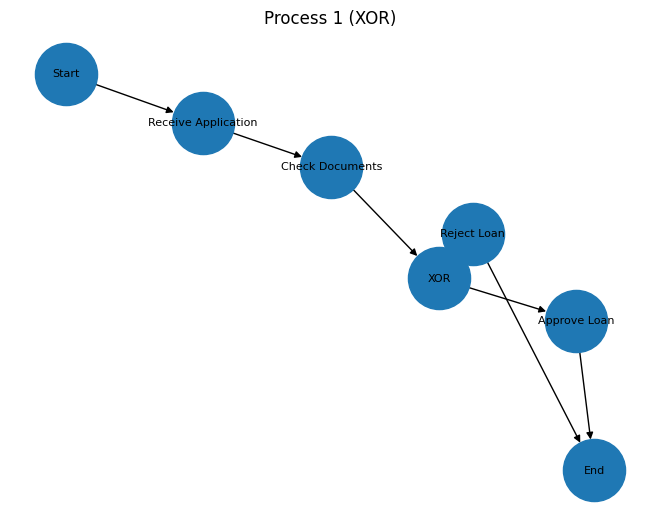

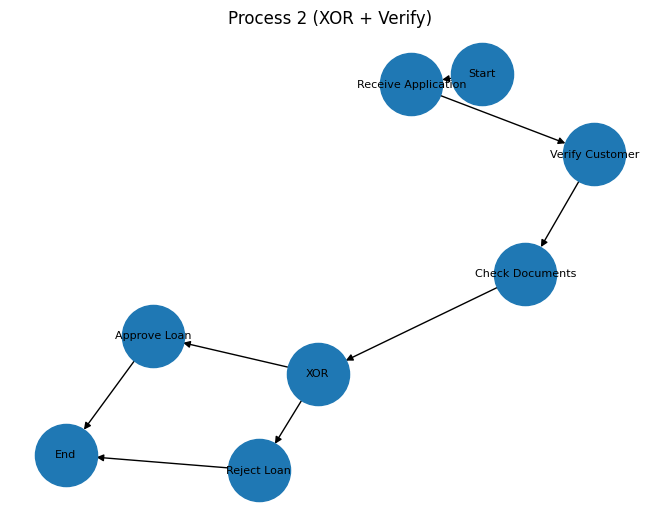


Similarity giữa 2 process: 0.879


In [15]:
# Install nếu chưa có
# !pip install networkx gensim scikit-learn matplotlib

import networkx as nx
import matplotlib.pyplot as plt
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ======================
# 1. Tạo 2 BPMN graph
# ======================

G1 = nx.DiGraph()
G1.add_edges_from([
    ("Start", "Receive Application"),
    ("Receive Application", "Check Documents"),
    ("Check Documents", "XOR"),
    ("XOR", "Approve Loan"),
    ("XOR", "Reject Loan"),
    ("Approve Loan", "End"),
    ("Reject Loan", "End")
])

G2 = nx.DiGraph()
G2.add_edges_from([
    ("Start", "Receive Application"),
    ("Receive Application", "Verify Customer"),
    ("Verify Customer", "Check Documents"),
    ("Check Documents", "XOR"),
    ("XOR", "Approve Loan"),
    ("XOR", "Reject Loan"),
    ("Approve Loan", "End"),
    ("Reject Loan", "End")
])

# ======================
# 2. Vẽ graph
# ======================
def draw_graph(G, title):
    pos = nx.spring_layout(G, seed=42)

    plt.figure()
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=2000,
        font_size=8
    )
    plt.title(title)
    plt.show()

draw_graph(G1, "Process 1 (XOR)")
draw_graph(G2, "Process 2 (XOR + Verify)")

# ======================
# 3. Gán label node
# ======================
def assign_labels(G):
    labels = {}
    for n in G.nodes():
        if n in ["Start", "End"]:
            labels[n] = "event"
        elif "XOR" in n:
            labels[n] = "gateway"
        else:
            labels[n] = "task"
    return labels

# ======================
# 4. WL feature extraction
# ======================
def wl_features(G, labels, iterations=2):
    labels = labels.copy()
    features = []

    features.extend(labels.values())

    for _ in range(iterations):
        new_labels = {}
        for node in G.nodes():
            neighbors = list(G.successors(node)) + list(G.predecessors(node))
            neighbor_labels = sorted([labels[n] for n in neighbors])
            new_label = labels[node] + "_" + "_".join(neighbor_labels)
            new_labels[node] = new_label

        labels = new_labels
        features.extend(labels.values())

    return features

# ======================
# 5. Tạo document
# ======================
docs = []
for i, G in enumerate([G1, G2]):
    labels = assign_labels(G)
    feats = wl_features(G, labels)
    docs.append(TaggedDocument(words=feats, tags=[f"graph_{i}"]))

# ======================
# 6. Train Doc2Vec
# ======================
model = Doc2Vec(vector_size=64, min_count=1, epochs=100)
model.build_vocab(docs)
model.train(docs, total_examples=model.corpus_count, epochs=model.epochs)

# ======================
# 7. Tính similarity
# ======================
embeddings = np.array([model.dv[f"graph_{i}"] for i in range(2)])
sim = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]

print("\nSimilarity giữa 2 process:", round(sim, 4))

# Thực hiện process XOR dơn giản
1.  biến BPMN thành graph
2. tạo node2vec
3. gom cụm bằng k-mean với đặc điểm, cấu trúc giống nhau
4. giải thích

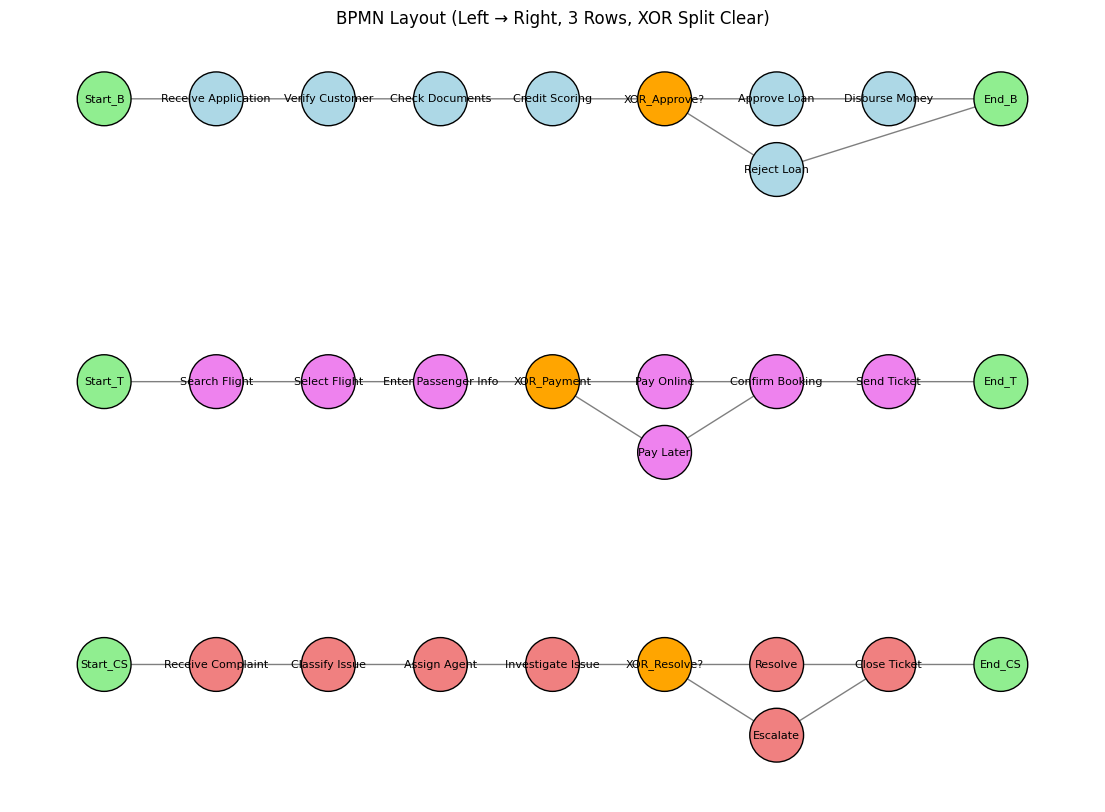

Computing transition probabilities:   0%|          | 0/30 [00:00<?, ?it/s]

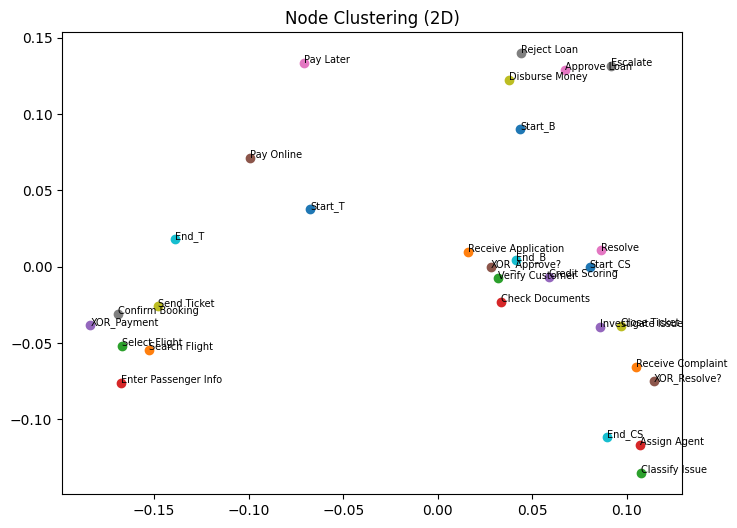

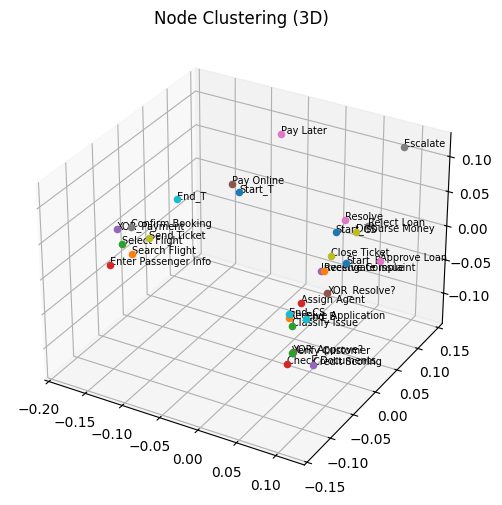


=== CLUSTER RESULT ===

Cluster 2:
 - Start_B
 - Receive Application
 - Verify Customer
 - Check Documents
 - Credit Scoring
 - XOR_Approve?
 - Approve Loan
 - Reject Loan
 - Disburse Money
 - End_B

Cluster 0:
 - Start_T
 - Search Flight
 - Select Flight
 - Enter Passenger Info
 - XOR_Payment
 - Pay Online
 - Pay Later
 - Confirm Booking
 - Send Ticket
 - End_T

Cluster 1:
 - Start_CS
 - Receive Complaint
 - Classify Issue
 - Assign Agent
 - Investigate Issue
 - XOR_Resolve?
 - Resolve
 - Escalate
 - Close Ticket
 - End_CS

=== INTERPRETATION ===

- Node2Vec học embedding dựa trên structure (neighbor, path, gateway).
- Các node có vị trí và vai trò giống nhau sẽ gần nhau trong vector space.

Kỳ vọng clustering:
1. Cluster chứa các node thuộc cùng domain:
   - Banking (loan, credit, approve)
   - Travel (booking, flight, payment)
   - Customer Service (complaint, resolve)

2. Hoặc cluster theo FUNCTION:
   - Start/End nodes
   - Gateway nodes (XOR)
   - Processing tasks

=> Điều này c

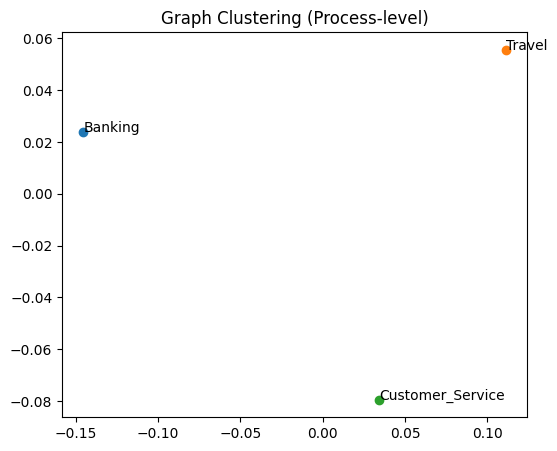

In [13]:
# Install nếu chưa có
# !pip install networkx node2vec scikit-learn matplotlib

import networkx as nx
import matplotlib.pyplot as plt
from node2vec import Node2Vec
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# =========================
# 1. TẠO BPMN GRAPH (3 DOMAIN)
# =========================

G = nx.DiGraph()

# ---- BANKING ----
banking_nodes = [
    "Start_B", "Receive Application", "Verify Customer", "Check Documents",
    "Credit Scoring", "XOR_Approve?", "Approve Loan", "Reject Loan",
    "Disburse Money", "End_B"
]

# ---- TRAVEL ----
travel_nodes = [
    "Start_T", "Search Flight", "Select Flight", "Enter Passenger Info",
    "XOR_Payment", "Pay Online", "Pay Later",
    "Confirm Booking", "Send Ticket", "End_T"
]

# ---- CUSTOMER SERVICE ----
cs_nodes = [
    "Start_CS", "Receive Complaint", "Classify Issue", "Assign Agent",
    "Investigate Issue", "XOR_Resolve?", "Resolve", "Escalate",
    "Close Ticket", "End_CS"
]

# Add nodes
G.add_nodes_from(banking_nodes + travel_nodes + cs_nodes)

# ---- BANKING EDGES ----
G.add_edges_from([
    ("Start_B", "Receive Application"),
    ("Receive Application", "Verify Customer"),
    ("Verify Customer", "Check Documents"),
    ("Check Documents", "Credit Scoring"),
    ("Credit Scoring", "XOR_Approve?"),
    ("XOR_Approve?", "Approve Loan"),
    ("XOR_Approve?", "Reject Loan"),
    ("Approve Loan", "Disburse Money"),
    ("Disburse Money", "End_B"),
    ("Reject Loan", "End_B")
])

# ---- TRAVEL EDGES ----
G.add_edges_from([
    ("Start_T", "Search Flight"),
    ("Search Flight", "Select Flight"),
    ("Select Flight", "Enter Passenger Info"),
    ("Enter Passenger Info", "XOR_Payment"),
    ("XOR_Payment", "Pay Online"),
    ("XOR_Payment", "Pay Later"),
    ("Pay Online", "Confirm Booking"),
    ("Pay Later", "Confirm Booking"),
    ("Confirm Booking", "Send Ticket"),
    ("Send Ticket", "End_T")
])

# ---- CUSTOMER SERVICE EDGES ----
G.add_edges_from([
    ("Start_CS", "Receive Complaint"),
    ("Receive Complaint", "Classify Issue"),
    ("Classify Issue", "Assign Agent"),
    ("Assign Agent", "Investigate Issue"),
    ("Investigate Issue", "XOR_Resolve?"),
    ("XOR_Resolve?", "Resolve"),
    ("XOR_Resolve?", "Escalate"),
    ("Resolve", "Close Ticket"),
    ("Escalate", "Close Ticket"),
    ("Close Ticket", "End_CS")
])

# =========================
# 2. VẼ GRAPH
# =========================
plt.figure(figsize=(14, 10))

# ======================
# 1. DEFINE LAYER (QUAN TRỌNG)
# ======================

layers = {
    # BANKING
    "Start_B": 0,
    "Receive Application": 1,
    "Verify Customer": 2,
    "Check Documents": 3,
    "Credit Scoring": 4,
    "XOR_Approve?": 5,
    "Approve Loan": 6,
    "Reject Loan": 6,
    "Disburse Money": 7,
    "End_B": 8,

    # TRAVEL
    "Start_T": 0,
    "Search Flight": 1,
    "Select Flight": 2,
    "Enter Passenger Info": 3,
    "XOR_Payment": 4,
    "Pay Online": 5,
    "Pay Later": 5,
    "Confirm Booking": 6,
    "Send Ticket": 7,
    "End_T": 8,

    # CUSTOMER SERVICE
    "Start_CS": 0,
    "Receive Complaint": 1,
    "Classify Issue": 2,
    "Assign Agent": 3,
    "Investigate Issue": 4,
    "XOR_Resolve?": 5,
    "Resolve": 6,
    "Escalate": 6,
    "Close Ticket": 7,
    "End_CS": 8
}

# ======================
# 2. TẠO POS (GRID LAYOUT)
# ======================

pos = {}

def build_row(nodes, y_offset):
    layer_count = {}
    for n in nodes:
        x = layers[n]

        # xử lý node trùng layer (ví dụ XOR split)
        layer_count.setdefault(x, 0)
        y = y_offset - layer_count[x]*0.5

        pos[n] = np.array([x, y])
        layer_count[x] += 1

# 3 hàng (trên → dưới)
banking_nodes = [n for n in G.nodes() if "_B" in n or n in [
    "Receive Application","Verify Customer","Check Documents",
    "Credit Scoring","XOR_Approve?","Approve Loan","Reject Loan","Disburse Money"
]]

travel_nodes = [n for n in G.nodes() if "_T" in n or n in [
    "Search Flight","Select Flight","Enter Passenger Info",
    "XOR_Payment","Pay Online","Pay Later","Confirm Booking","Send Ticket"
]]

cs_nodes = [n for n in G.nodes() if "_CS" in n or n in [
    "Receive Complaint","Classify Issue","Assign Agent",
    "Investigate Issue","XOR_Resolve?","Resolve","Escalate","Close Ticket"
]]

build_row(banking_nodes, y_offset=2)
build_row(travel_nodes, y_offset=0)
build_row(cs_nodes, y_offset=-2)

# ======================
# 3. COLOR
# ======================
def get_color(n):
    if "XOR" in n:
        return "orange"
    elif "Start" in n or "End" in n:
        return "lightgreen"
    elif "_B" in n or n in banking_nodes:
        return "lightblue"
    elif "_T" in n or n in travel_nodes:
        return "violet"
    else:
        return "lightcoral"

node_colors = [get_color(n) for n in G.nodes()]

# ======================
# 4. DRAW
# ======================
nx.draw_networkx_edges(G, pos, alpha=0.5)

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=1500,
    edgecolors="black"
)

nx.draw_networkx_labels(
    G, pos,
    font_size=8
)

plt.title("BPMN Layout (Left → Right, 3 Rows, XOR Split Clear)")
plt.axis("off")
plt.show()

# =========================
# 3. NODE2VEC EMBEDDING
# =========================
node2vec = Node2Vec(G, dimensions=64, walk_length=10, num_walks=50, workers=2)
model = node2vec.fit(window=5, min_count=1)

# Lấy embedding cho từng node
nodes = list(G.nodes())
embeddings = np.array([model.wv[n] for n in nodes])

# =========================
# 4. K-MEANS CLUSTERING
# =========================
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(embeddings)

# =========================
# 5. GIẢM CHIỀU (2D + 3D)
# =========================
pca_2d = PCA(n_components=2)
emb_2d = pca_2d.fit_transform(embeddings)

pca_3d = PCA(n_components=3)
emb_3d = pca_3d.fit_transform(embeddings)

# =========================
# 6. VẼ 2D
# =========================
plt.figure(figsize=(8,6))
for i, node in enumerate(nodes):
    plt.scatter(emb_2d[i,0], emb_2d[i,1])
    plt.text(emb_2d[i,0], emb_2d[i,1], node, fontsize=7)

plt.title("Node Clustering (2D)")
plt.show()

# =========================
# 7. VẼ 3D
# =========================
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for i, node in enumerate(nodes):
    ax.scatter(emb_3d[i,0], emb_3d[i,1], emb_3d[i,2])
    ax.text(emb_3d[i,0], emb_3d[i,1], emb_3d[i,2], node, size=7)

ax.set_title("Node Clustering (3D)")
plt.show()

# =========================
# 8. IN KẾT QUẢ CLUSTER
# =========================
clusters = {}
for node, label in zip(nodes, labels):
    clusters.setdefault(label, []).append(node)

print("\n=== CLUSTER RESULT ===")
for k, v in clusters.items():
    print(f"\nCluster {k}:")
    for node in v:
        print(" -", node)

# =========================
# 9. GIẢI THÍCH (QUAN TRỌNG)
# =========================
print("\n=== INTERPRETATION ===")
print("""
- Node2Vec học embedding dựa trên structure (neighbor, path, gateway).
- Các node có vị trí và vai trò giống nhau sẽ gần nhau trong vector space.

Kỳ vọng clustering:
1. Cluster chứa các node thuộc cùng domain:
   - Banking (loan, credit, approve)
   - Travel (booking, flight, payment)
   - Customer Service (complaint, resolve)

2. Hoặc cluster theo FUNCTION:
   - Start/End nodes
   - Gateway nodes (XOR)
   - Processing tasks

=> Điều này cho thấy:
- Model không chỉ học tên node mà còn học cấu trúc quy trình.
- Có thể dùng để:
    + Detect pattern giống nhau giữa các process
    + Gom nhóm activity (process mining)
    + Tối ưu workflow (cost / path)
""")

from gensim.models.doc2vec import Doc2Vec, TaggedDocument

# =========================
# 1. TÁCH 3 GRAPH RIÊNG
# =========================
G_bank = G.subgraph(banking_nodes).copy()
G_travel = G.subgraph(travel_nodes).copy()
G_cs = G.subgraph(cs_nodes).copy()

graphs = [G_bank, G_travel, G_cs]
graph_names = ["Banking", "Travel", "Customer_Service"]

# =========================
# 2. WL FEATURE (Graph2Vec idea)
# =========================
def wl_features(G, iterations=2):
    labels = {n: "task" for n in G.nodes()}

    for n in G.nodes():
        if "Start" in n or "End" in n:
            labels[n] = "event"
        elif "XOR" in n:
            labels[n] = "gateway"

    features = list(labels.values())

    for _ in range(iterations):
        new_labels = {}
        for node in G.nodes():
            neighbors = list(G.successors(node)) + list(G.predecessors(node))
            neighbor_labels = sorted([labels[n] for n in neighbors])
            new_labels[node] = labels[node] + "_" + "_".join(neighbor_labels)

        labels = new_labels
        features.extend(labels.values())

    return features

# =========================
# 3. TẠO DOCUMENT
# =========================
docs = []
for i, g in enumerate(graphs):
    feats = wl_features(g)
    docs.append(TaggedDocument(words=feats, tags=[graph_names[i]]))

# =========================
# 4. TRAIN GRAPH EMBEDDING
# =========================
model_graph = Doc2Vec(vector_size=32, min_count=1, epochs=100)
model_graph.build_vocab(docs)
model_graph.train(docs, total_examples=model_graph.corpus_count, epochs=model_graph.epochs)

# =========================
# 5. LẤY EMBEDDING
# =========================
graph_embeddings = np.array([model_graph.dv[name] for name in graph_names])

# =========================
# 6. CLUSTER GRAPH
# =========================
kmeans_graph = KMeans(n_clusters=2, random_state=42)
graph_labels = kmeans_graph.fit_predict(graph_embeddings)

# =========================
# 7. KẾT QUẢ
# =========================
print("\n=== GRAPH CLUSTERING RESULT ===")
for name, label in zip(graph_names, graph_labels):
    print(f"{name} → Cluster {label}")

# =========================
# 8. VISUALIZE (2D)
# =========================
pca = PCA(n_components=2)
emb_2d_graph = pca.fit_transform(graph_embeddings)

plt.figure(figsize=(6,5))
for i, name in enumerate(graph_names):
    plt.scatter(emb_2d_graph[i,0], emb_2d_graph[i,1])
    plt.text(emb_2d_graph[i,0], emb_2d_graph[i,1], name)

plt.title("Graph Clustering (Process-level)")
plt.show()